# MS2 scoring, step by step

For each candidate structure (SMILES) of a feature we generate theoretical
fragments in silico with **RDKit BRICS**, turn them into ions under **several adducts**,
and check which experimental MS2 peaks they can explain.

Two fragmentation methods (both use BRICS bonds):
- **`BRICSDecompose`** - break all BRICS bonds at once (smallest fragments).
- **`FragmentOnBonds`** - break combinations of 1~N BRICS bonds (keeps larger
  fragments, so diagnostic ions such as PC 184 / TG DAG survive). N = `N` below.

- **Part 1** takes one example candidate all the way through: cut -> see structures ->
  cap -> mass -> m/z -> match -> peak-match table.
- **Part 2** runs every candidate and compares their coverage.

Ion model: SMILES are the **neutral** compound; each neutral fragment is projected onto
**6 positive adducts** (`M+H, M+, M+Na, M+2H, 2M+H, M+NH4`) from ipaPy2's `adducts.csv`
(`m/z = (Mult·M)/Charge + Mass`). Already-charged fragments are kept as their own ion.
The ppm tolerance (and low-mass Da floor) are the Settings knobs `PPM` / `MIN_DA`.
(Long output tables scroll automatically - VS Code setting `notebook.output.scrolling`.)

## 0. Imports

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import BRICS
import ms2_scoring_stepwise as bf

## Settings (the only inputs)
- **`FEATURE`** - which feature file to use.
- **`EXAMPLE`** - candidate to walk through / query; `None` -> first candidate in the file.
- **`METHOD`** - fragmentation algorithm; `None` -> reuse the last choice
  (first time ever -> `BRICSDecompose`). Options: `"BRICSDecompose"`, `"FragmentOnBonds"`.
- **`N`** - max bonds cut per combination (only used by `FragmentOnBonds`; 2 is the usual
  sweet spot). Overrides `MAX_BREAKS` in ms2_scoring_stepwise.py.
- **`PPM`** - m/z matching tolerance in ppm, applied to every peak match (Task 1 & 2).
  Overrides `TOL_PPM` in ms2_scoring_stepwise.py via `bf.set_tolerance(PPM)`.
- **`MIN_DA`** - absolute floor of the match window in Da. The window is
  `max(MIN_DA, m/z * PPM)`, so MIN_DA governs the low-mass end where ppm is tiny
  (0.005 keeps the prior behaviour; lower it to let ppm control small ions too).

In [2]:
FEATURE = "FT6080"       # e.g. "FT4679" or "FT6080"
EXAMPLE = None           # candidate name, or None -> first candidate in the file
METHOD  = "FragmentOnBonds"           # "BRICSDecompose" / "FragmentOnBonds", or None -> reuse last
N       = 2              # FragmentOnBonds: cut up to N bonds
PPM     = 20              # m/z matching tolerance in ppm (peak matching, Task 1 & 2)
MIN_DA  = 0.005          # absolute floor of the match window in Da: max(MIN_DA, m/z*PPM)

### Resolve the algorithm
`resolve_method` remembers your last choice on disk.

In [3]:
METHOD = bf.resolve_method(METHOD)
bf.set_tolerance(PPM, MIN_DA)                # apply the tolerance from Settings
print("Fragmentation method:", METHOD, "| N =", N, "| ppm =", PPM, "| min_da =", MIN_DA)

Fragmentation method: FragmentOnBonds | N = 2 | ppm = 20 | min_da = 0.005


## 1. Read data (annotation table + MS2 peak list)

`bf.load` is the single entry point for the spectrum, and it is **where the peak list is filtered** - once, at the very start, so Task 1, Task 2 and the score all work on exactly the same peaks:

1. **peaks with m/z >= the precursor m/z are removed** (`drop_above_precursor=True`). A product ion cannot be heavier than the ion it came from, so anything at or above the precursor is the surviving precursor itself, its 13C isotopes, or a co-isolated contaminant - never a fragment. They also leave the score's denominator, so the score measures the fragment signal only.
2. **noise floor**: peaks below `MIN_REL_INT` (1% relative intensity) are dropped, which keeps ~95% of the signal.

The cell below prints what each filter removed.


In [4]:
ann, peaks = bf.load(FEATURE)                       # both filters applied here
prec = bf.read_precursor(FEATURE)          # precursor m/z -> tag isotope peaks (A3)

raw = bf.load(FEATURE, min_rel_int=0, drop_above_precursor=False)[1]     # what was there before
above = [mz for mz, _ in raw if mz >= prec]
print("peaks:", len(raw), "raw ->", len(peaks), "kept")
print("  dropped >= precursor (%.4f):" % prec, len(above), [round(mz, 4) for mz in above])
print("  dropped below %.0f%% intensity:" % bf.MIN_REL_INT, len(raw) - len(above) - len(peaks))

name = EXAMPLE or ann["name"].iloc[0]      # resolved once; used all through Part 1
print("feature:", FEATURE, "| example candidate:", name, "| precursor m/z:", prec)
ann[["name", "formula", "adduct", "smiles"]]


peaks: 125 raw -> 56 kept
  dropped >= precursor (872.7541): 2 [873.694, 874.6965]
  dropped below 1% intensity: 67
feature: FT6080 | example candidate: TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z)) | precursor m/z: 872.754089


,name,formula,adduct,smiles
0,"TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z))",C55H102NO6,M+NH4,[H][C@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCC\C=C...
1,"TG(18:1(11Z)/16:0/18:3(9Z,12Z,15Z))",C55H102NO6,M+NH4,[H][C@](COC(=O)CCCCCCCCC\C=C/CCCCCC)(COC(=O)CC...
2,"TG(18:1(11Z)/16:1(9Z)/18:2(9Z,12Z))",C55H102NO6,M+NH4,[H][C@](COC(=O)CCCCCCCCC\C=C/CCCCCC)(COC(=O)CC...
3,"TG(16:1(9Z)/18:1(9Z)/18:2(9Z,12Z))",C55H102NO6,M+NH4,[H][C@](COC(=O)CCCCCCC\C=C/CCCCCC)(COC(=O)CCCC...
4,"TG(16:0/18:2(9Z,12Z)/18:2(9Z,12Z))",C55H102NO6,M+NH4,[H][C@](COC(=O)CCCCCCCCCCCCCCC)(COC(=O)CCCCCCC...
5,"TG(18:1(9Z)/16:0/18:3(9Z,12Z,15Z))",C55H102NO6,M+NH4,[H][C@](COC(=O)CCCCCCC\C=C/CCCCCCCC)(COC(=O)CC...
6,"TG(16:1(9Z)/18:1(11Z)/18:2(9Z,12Z))",C55H102NO6,M+NH4,[H][C@](COC(=O)CCCCCCC\C=C/CCCCCC)(COC(=O)CCCC...


# Part 1 - one candidate, end to end
Everything below is about the single example candidate `name`
(fragmentation = `METHOD`, depth `N`).

### 2. Pick the example candidate

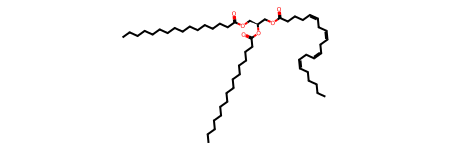

In [5]:
smi = ann.loc[ann["name"] == name, "smiles"].iloc[0]
mol = Chem.MolFromSmiles(smi)     # tutorial: Chem.MolFromSmiles
mol

### 3. Cut - fragment with the chosen METHOD (and N)
Fragments carry dummy atoms `[n*]` marking the broken bonds.

In [6]:
pieces = bf.brics_cut(mol, METHOD, N)
print(len(pieces), "raw fragments")
pieces

65 raw fragments


['*OC(=O)CCCCCCCCCCCCCCC',
 '*O[44*]',
 '[1*]OC(=O)CCCCCCCCCCCCCCC',
 '[1*]O[3*]',
 '[2*]C(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@@H](COC(=O)CCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCCC)OC(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@@H](COC(=O)CCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCCC)O[44*]',
 '[2*]C[C@@H](COC(=O)CCC/C=C\\C/C=C\\C/C=C\\CC=[37*])OC(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@@H](COC(=O)CCC/C=C\\C/C=C\\CC=[34*])OC(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@@H](COC(=O)CCC/C=C\\CC=[31*])OC(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@@H](COC(=O)CCCC=[28*])OC(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@@H](CO[22*])OC(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@@H](C[21*])OC(=O)CCCCCCCCCCCCCCC',
 '[2*]C[C@H]([43*])COC(=O)CCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCCC',
 '[20*]OC(=O)CCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCCC',
 '[20*]OC(=O)CCC/C=C\\C/C=C\\C/C=C\\CC=[37*]',
 '[20*]OC(=O)CCC/C=C\\C/C=C\\CC=[34*]',
 '[20*]OC(=O)CCC/C=C\\CC=[31*]',
 '[20*]OC(=O)CCCC=[28*]',
 '[20*]O[22*]',
 '[21*]C(=O)CCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCCC',
 '[21*]C(=O)CCC/C=C\\C/C=C\\C/C=C\\CC=[37*]',
 '[21*]C(=O

### 4. Fragment structures - `Draw.MolsToGridImage` (tutorial)
The pieces from step 3, drawn as complete molecules (dummy atoms capped with H - see step 5).
Image is also saved into `./figures`.

[adducts] 6 loaded from web (github raw): M+H, M+, M+Na, M+2H, 2M+H, M+NH4


d:\miniconda3\envs\msfrag\Lib\site-packages\rdkit\Chem\Draw\IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


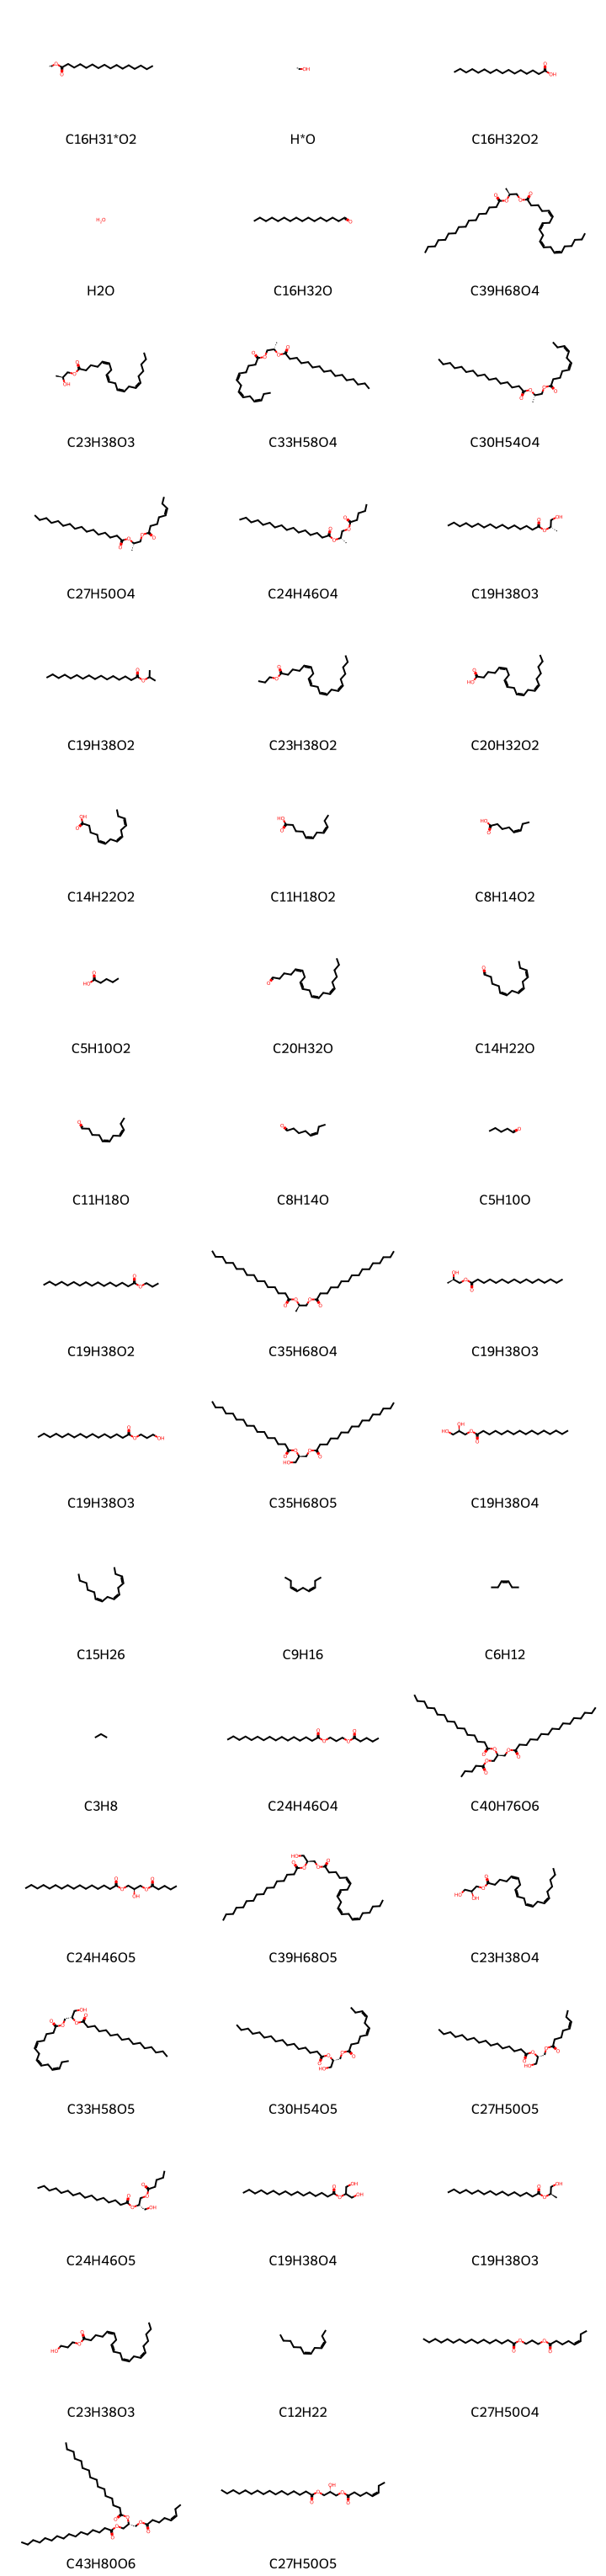

In [7]:
ex = [{**bf.analyze(peaks, smi, METHOD, N, precursor_mz=prec), "name": name, "id": ""}]   # this example's analysis
bf.draw_fragments(ex, name)

### 5. Cap - replace dummy atoms `[n*]` with H

In [8]:
[Chem.MolToSmiles(m) for p in pieces if (m := bf.cap(p)) is not None]

['*OC(=O)CCCCCCCCCCCCCCC',
 '*O',
 'CCCCCCCCCCCCCCCC(=O)O',
 'O',
 'CCCCCCCCCCCCCCCC=O',
 'CCCCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCC(=O)OC[C@H](C)OC(=O)CCCCCCCCCCCCCCC',
 'CCCCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCC(=O)OC[C@H](C)O',
 'CC/C=C\\C/C=C\\C/C=C\\CCCC(=O)OC[C@H](C)OC(=O)CCCCCCCCCCCCCCC',
 'CC/C=C\\C/C=C\\CCCC(=O)OC[C@H](C)OC(=O)CCCCCCCCCCCCCCC',
 'CC/C=C\\CCCC(=O)OC[C@H](C)OC(=O)CCCCCCCCCCCCCCC',
 'CCCCCCCCCCCCCCCC(=O)O[C@@H](C)COC(=O)CCCC',
 'CCCCCCCCCCCCCCCC(=O)O[C@@H](C)CO',
 'CCCCCCCCCCCCCCCC(=O)OC(C)C',
 'CCCCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCC(=O)OCCC',
 'CCCCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCC(=O)O',
 'CC/C=C\\C/C=C\\C/C=C\\CCCC(=O)O',
 'CC/C=C\\C/C=C\\CCCC(=O)O',
 'CC/C=C\\CCCC(=O)O',
 'CCCCC(=O)O',
 'O',
 'CCCCC/C=C\\C/C=C\\C/C=C\\C/C=C\\CCCC=O',
 'CC/C=C\\C/C=C\\C/C=C\\CCCC=O',
 'CC/C=C\\C/C=C\\CCCC=O',
 'CC/C=C\\CCCC=O',
 'CCCCC=O',
 'CCCCCCCCCCCCCCCC(=O)OCCC',
 'CCCCCCCCCCCCCCCC(=O)OC[C@@H](C)OC(=O)CCCCCCCCCCCCCCC',
 'CCCCCCCCCCCCCCCC(=O)OC[C@@H](C)O',
 'CCCCCCCCCCCCCCCC(=O)OCCCO',

### 6. Mass - formula and exact mass of each fragment

In [9]:
frags = bf.brics_fragments(mol, METHOD, N)
pd.DataFrame(frags)

,smiles,formula,mass,charge
0,*OC(=O)CCCCCCCCCCCCCCC,C16H31*O2,255.232405,0
1,*O,H*O,17.002740,0
2,CCCCCCCCCCCCCCCC(=O)O,C16H32O2,256.240230,0
3,O,H2O,18.010565,0
4,CCCCCCCCCCCCCCCC=O,C16H32O,240.245316,0
5,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H](C)...,C39H68O4,600.511761,0
6,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H](C)O,C23H38O3,362.282095,0
7,CC/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H](C)OC(=O)CCC...,C33H58O4,518.433510,0
8,CC/C=C\C/C=C\CCCC(=O)OC[C@H](C)OC(=O)CCCCCCCCC...,C30H54O4,478.402210,0
9,CC/C=C\CCCC(=O)OC[C@H](C)OC(=O)CCCCCCCCCCCCCCC,C27H50O4,438.370910,0


### 7. Theoretical m/z — 6 adducts (from ipaPy2 `adducts.csv`)

`fragment_ions` projects every **neutral** fragment onto the 6 selected adducts
(`M+H, M+, M+Na, M+2H, 2M+H, M+NH4`) using the ipaPy2 formula
`m/z = (Mult·M)/Charge + Mass`, with `Mult/Charge/Mass` read from Francesco's
`adducts.csv` (GitHub raw, local fallback). Fragments that already carry a charge
(choline⁺, phosphate⁻) are kept as their own single `intrinsic` ion, not stacked
with adducts. The matrix below is one row per fragment, one column per adduct
(`intrinsic` last); `ions` keeps the flat list that feeds the matching in ### 8.

In [10]:
ions = bf.fragment_ions(frags)          # flat list (fragment × adduct) — feeds ### 8 matching
bf.theoretical_matrix(frags).style.format("{:.4f}", na_rep="")   # matrix; blank = no ion there

adduct,M+H,M+,M+Na,M+2H,2M+H,M+NH4
fragment,,,,,,
C11H18O CC/C=C\C/C=C\CCCC=O,167.1430,166.1352,189.1250,84.0752,333.2788,184.1696
C11H18O2 CC/C=C\C/C=C\CCCC(=O)O,183.1380,182.1301,205.1199,92.0726,365.2686,200.1645
C12H22 CC/C=C\C/C=C\CCCCC,167.1794,166.1716,189.1614,84.0934,333.3516,184.2060
C14H22O CC/C=C\C/C=C\C/C=C\CCC...,207.1743,206.1665,229.1563,104.0908,413.3414,224.2009
C14H22O2 CC/C=C\C/C=C\C/C=C\CCC...,223.1693,222.1614,245.1512,112.0883,445.3312,240.1958
C15H26 CC/C=C\C/C=C\C/C=C\CCC...,207.2107,206.2029,229.1927,104.1090,413.4142,224.2373
C16H31*O2 *OC(=O)CCCCCCCCCCCCCCC,256.2397,255.2319,278.2216,128.6235,511.4721,273.2662
C16H32O CCCCCCCCCCCCCCCC=O,241.2526,240.2448,263.2345,121.1299,481.4979,258.2791
C16H32O2 CCCCCCCCCCCCCCCC(=O)O,257.2475,256.2397,279.2294,129.1274,513.4877,274.2741


### 8. Peak matching - which experimental peaks these ions explain

In [11]:
matched = [(round(mz, 4), round(ri, 3)) for mz, ri in peaks
           if any(bf.match(mz, io["mz"]) for io in ions)]
pd.DataFrame(matched, columns=["exp_mz", "rel_int"])

,exp_mz,rel_int
0,67.0544,23.211
1,85.1012,6.858
2,107.0855,2.938
3,109.1012,7.634
4,147.1169,1.802
5,149.1324,2.835
6,263.2368,5.548
7,337.2721,1.208
8,575.5035,100.000
9,601.5189,94.046


### 9. Annotated peaks (Task 1)
Only the peaks a theoretical fragment can explain, each with the fragment's class name,
formula, the adduct that matched (`best_adduct`), ppm error, and how many
`(fragment, adduct)` combinations fell in the window (`n_hits`; `alt_adducts` lists the
other adducts that also matched — `n_hits > 1` flags an ambiguous peak worth a look).

In [12]:
pd.set_option("display.max_rows", None)
bf.style_annotated(ex, name)            # annotated peaks, styled (n_hits>1 highlighted yellow)

,exp_mz,rel_int,kind,name,formula,best_adduct,theo_mz,ppm,n_hits,alt_adducts,n_frag
0,575.5035,100.0,fragment,diacylglycerol (DAG),C35H68O4,M+Na,575.5010,+4.5,1,,1
1,601.5189,94.0,fragment,diacylglycerol (DAG),C39H68O4,M+H,601.5190,-0.3,2,,2
2,67.0544,23.2,fragment,,C3H8,M+Na,67.0518,+37.8,1,,1
3,109.1012,7.6,fragment,,C6H14,M+Na,109.0988,+22.1,1,,1
4,85.1012,6.9,fragment,,C6H12,M+H,85.1012,+0.4,1,,1
5,263.2368,5.5,fragment,,C16H32O,M+Na,263.2345,+8.6,1,,1
6,107.0855,2.9,fragment,,C6H12,M+Na,107.0831,+21.9,1,,1
7,149.1324,2.8,fragment,,C9H18,M+Na,149.1301,+15.4,1,,1
8,147.1169,1.8,fragment,,C9H16,M+Na,147.1144,+16.7,1,,1
9,337.2721,1.2,fragment,,C19H38O3,M+Na,337.2713,+2.3,4,,4


**Structures of the annotated fragments** - each captioned with the experimental *m/z* it accounts for and its class name.

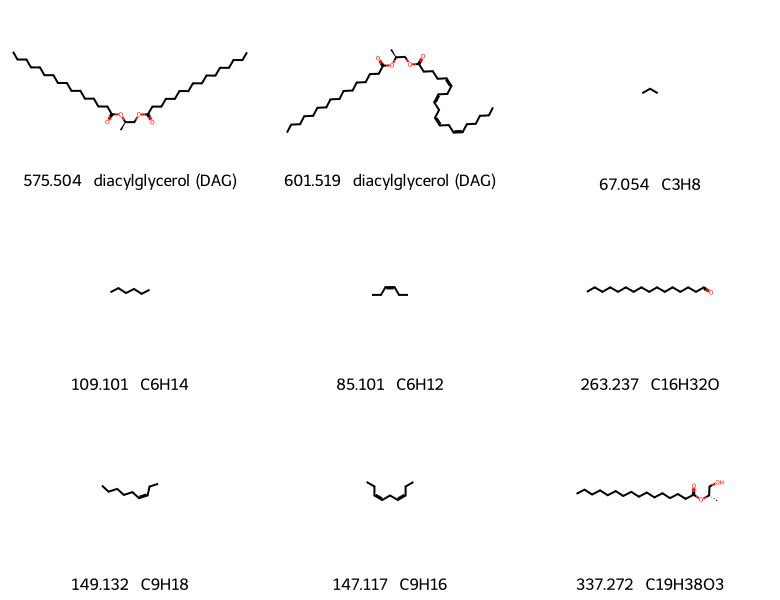

In [13]:
bf.draw_annotated_peaks(ex, name)

### Unexplained peaks
Experimental peaks that **no** theoretical fragment explains (precursor and 13C-isotope peaks already removed). Kept compact: m/z + intensity.

In [14]:
bf.unexplained_table(ex, name)

,exp_mz,rel_int
0,577.5189,83.674
1,81.0699,19.751
2,95.0855,18.023
3,69.0700,17.964
4,603.5343,11.020
5,121.1012,9.418
6,79.0543,9.327
7,97.1012,8.581
8,83.0855,7.649
9,135.1167,6.769


### Adduct contribution (output ③) — was adding the 6 adducts worth it?

Per adduct: how many fragment peaks it explained and their share of the **total measured
intensity**. A spectrum dominated by `M+H` (plus `intrinsic` for already-charged
fragments) means the extra adducts added little; `M+Na` / `M+2H` rows that appear only at
low intensity and high ppm (check `n_hits` / `ppm` in ### 9) are usually low-mass false
positives, floored in by `MIN_DA` — tighten `MIN_DA` / `PPM` to remove them.

In [15]:
bf.adduct_breakdown(ex[0])              # per-adduct: n peaks + % of total intensity

,adduct,n_peaks,pct_intensity
0,M+H,2,19.0
1,M+Na,8,27.3


# Part 2 - all candidates
Run every candidate and compare how much of the spectrum each can explain.

### 10. Analyze every candidate (with the chosen METHOD and N)

`analyze_all` now also **scores** each candidate as it goes (Task 1 + Task 2 share of the spectrum, see section 17) and returns the list sorted by that score. The precursor adduct Task 2 needs is read from the annotation file.


In [16]:
cands = bf.analyze_all(FEATURE, METHOD, N)
print(len(cands), "candidates")

7 candidates


### 11. Coverage of each candidate
One row per SMILES; sorted by score. `score` = the headline number from section 17 (Task 1 + the diagnostic Task-2 losses, i.e. the structure-specific signal); `pct_intensity` is the Task-1-only share, for comparison. `n_theoretical` = number of theoretical ions (specificity check).


In [17]:
bf.coverage_table(cands)

,name,id,score,n_matched,n_total,pct_peaks,pct_intensity,n_theoretical
0,"TG(16:1(9Z)/18:1(9Z)/18:2(9Z,12Z))",HMDB0005440,66.3,13,56,23.2,46.9,306
1,"TG(18:1(11Z)/16:1(9Z)/18:2(9Z,12Z))",HMDB0010444,66.1,12,56,21.4,46.6,304
2,"TG(16:1(9Z)/18:1(11Z)/18:2(9Z,12Z))",HMDB0048618,66.1,12,56,21.4,46.6,300
3,"TG(18:1(11Z)/16:0/18:3(9Z,12Z,15Z))",HMDB0010440,65.5,9,56,16.1,45.4,345
4,"TG(18:1(9Z)/16:0/18:3(9Z,12Z,15Z))",HMDB0010451,64.6,9,56,16.1,44.5,320
5,"TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z))",HMDB0005363,64.0,10,56,17.9,46.2,260
6,"TG(16:0/18:2(9Z,12Z)/18:2(9Z,12Z))",HMDB0005390,62.6,9,56,16.1,42.4,229


### 12. Which candidate explains which key peak
Rows = candidates
columns = **every peak that at least one candidate can explain** (all-blank columns — rearrangement ions, precursor, isotopes — are dropped automatically, no arbitrary top-N cap).
✓ = that candidate has a theoretical fragment for that peak. Shows whether MS2 can tell the candidates apart.

In [18]:
key_peaks = bf.explained_peaks(cands)   # every peak >=1 candidate explains (drops dead columns)
bf.candidate_peak_matrix(cands, key_peaks)

,candidate,67.054,85.101,107.085,109.101,123.117,147.117,149.132,151.148,239.237,263.237,265.252,313.274,319.263,337.272,339.289,575.504,577.519,601.519,603.534
0,"TG(16:1(9Z)/18:1(9Z)/18:2(9Z,12Z))",✓,,,✓,✓,,✓,✓,✓,,✓,✓,✓,,✓,✓,✓,,✓
1,"TG(18:1(11Z)/16:1(9Z)/18:2(9Z,12Z))",✓,,,✓,✓,,✓,,✓,,✓,✓,✓,,✓,✓,✓,,✓
2,"TG(16:1(9Z)/18:1(11Z)/18:2(9Z,12Z))",✓,,,✓,✓,,✓,,✓,,✓,✓,✓,,✓,✓,✓,,✓
3,"TG(18:1(11Z)/16:0/18:3(9Z,12Z,15Z))",✓,✓,✓,,✓,✓,,,,✓,,,,✓,,✓,,✓,
4,"TG(18:1(9Z)/16:0/18:3(9Z,12Z,15Z))",✓,✓,✓,,,✓,,✓,,✓,,,,✓,,✓,,✓,
5,"TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z))",✓,✓,✓,✓,,✓,✓,,,✓,,,,✓,,✓,,✓,
6,"TG(16:0/18:2(9Z,12Z)/18:2(9Z,12Z))",✓,,,✓,,,✓,,,✓,✓,,,✓,✓,,✓,✓,


# Part 3 - Neutral losses (Task 2)

Instead of matching peaks to fragment *structures* (Parts 1-2), here we read the **mass differences**: precursor - peak and peak - peak, and explain each as a **neutral loss** (a small neutral molecule that left). Backed by two libraries in `ms2_scoring_stepwise.py`:
- `Library 1: _UNIVERSAL` - a fixed list of small neutrals any molecule can lose (water, NH3, CO ...).
- `Library 2: candidate_losses()` - head-group losses (SMARTS-gated) + fatty-acyl losses derived from each candidate; for an [M+NH4]+ precursor also the composed NH3 + acyl losses.

> **Scope: LIPIDS ONLY (for now).** The fatty-acyl part (`acyl_losses`) only recognises ester / fatty-acid chains - correct for PC and TG. Other variable substituents (sugars on glycosides, peptide residues, ether chains) are **not handled yet** and would appear as unexplained differences. The universal losses and head-group rules are general; only the acyl (variable-mass) part is lipid-specific.

*(View functions `precursor_losses` / `pairwise_losses` + figures still to be added.)*

### The "take off the hats" guard (real loss vs adduct swap)

Before the neutral-loss steps below, a safeguard: a mass gap is **not** a neutral loss when
the two ions are the *same* neutral fragment wearing different adduct "hats" (e.g.
`[X+NH4]⁺` vs `[X+H]⁺` differ by 17.027 — exactly an NH₃ loss). The guard strips each ion's
adduct to recover its neutral mass (`M = (m/z − Mass)·Charge / Mult`) and flags an
**adduct swap** only when the two neutral masses coincide. It runs silently inside
`precursor_losses` (### 13) / `pairwise_losses` (### 14) and only fires when a fragment is
actually seen under two adducts — uncommon, but it does happen here: on this TG example
candidate one `M+H / M+Na` pair (a low-mass C₆H₁₂ fragment, gap 21.98 Da) is tagged
`adduct swap` in ### 14 instead of being mislabelled as a 21.98 Da neutral loss. The cell
below calls the guard directly on clean examples so the logic is visible.

In [19]:
# The "take off the hats" guard, shown directly (it runs silently inside ### 13 / ### 14).
lut = bf._adduct_lookup()
tol = lambda mz: max(bf.TOL_MIN, mz * bf.TOL_PPM * 1e-6)
mh  = lambda M: bf.adduct_mz(M, lut["M+H"])
na  = lambda M: bf.adduct_mz(M, lut["M+Na"])
nh4 = lambda M: bf.adduct_mz(M, lut["M+NH4"])

core = 183.066   # phosphocholine neutral mass, as an example fragment
# same fragment under two adducts  ->  ADDUCT SWAP (a fake neutral loss, correctly caught)
print("[M+Na] vs [M+H]  (same fragment) ->", bf._adduct_swap_pair(na(core),  "M+Na",  mh(core), "M+H", tol(na(core)),  lut))
print("[M+NH4] vs [M+H] (gap 17.027*)   ->", bf._adduct_swap_pair(nh4(core), "M+NH4", mh(core), "M+H", tol(nh4(core)), lut))
# two DIFFERENT fragments (different neutral cores)  ->  NOT a swap, stays a real loss
print("[M+Na] frag A vs [M+H] frag B    ->", bf._adduct_swap_pair(na(183.066), "M+Na", mh(160.0), "M+H", tol(na(183.066)), lut))
print("\n* 17.027 = NH4 - H is exactly an NH3 loss mass; without the guard the NH4->H swap")
print("  would be mislabelled as an 'NH3 neutral loss' in ### 13.")

[M+Na] vs [M+H]  (same fragment) -> M+H / M+Na (same neutral 183.0660)
[M+NH4] vs [M+H] (gap 17.027*)   -> M+H / M+NH4 (same neutral 183.0660)
[M+Na] frag A vs [M+H] frag B    -> None

* 17.027 = NH4 - H is exactly an NH3 loss mass; without the guard the NH4->H swap
  would be mislabelled as an 'NH3 neutral loss' in ### 13.


## 13. Precursor → peak losses

Neutral loss to explain each peak = **theoretical precursor − peak** (the theoretical precursor removes the ~0.016 Da calibration offset). Every difference is matched against the neutral-loss library (`match_loss`); with `matched_only=True` **only the peaks that a neutral loss explains are shown** (the `(no loss)` rows are hidden — drop the flag to see every peak).

- For **TG** this reads out the acyl chains directly (peak = precursor − (NH3 + fatty acid)).
- For **PC** this side is mostly empty — PC keeps the charge on the head group, so its diagnostic information is in the peak↔peak view (Step 2), not here.

In [20]:
adduct = ann['adduct'].iloc[0]          # 'M+H' (FT4679) / 'M+NH4' (FT6080)
bf.precursor_losses(ex[0], adduct, matched_only=True)   # only peaks explained by a neutral loss

,exp_mz,rel_int,delta,matched,category,loss,formula,source,ppm,P,n_expl,all_expl
0,551.5033,1.347,321.2669,True,acyl bridge,NH3 + fatty acid 20:4 (RCOOH),NH3+C20H32O2,adduct+acyl,0.3,1.0,1,NH3 + fatty acid 20:4 (RCOOH) (1.0)


## 14. Peak ↔ peak losses (bridges)

Neutral loss = peak(high) − peak(low), matched against the library. Guards drop 13C isotope spacing (~1.00335) and gaps < 1.5 Da. Rows are grouped by `category`: diagnostic bridges (acyl / head-group) on top, generic hydrocarbon spacing (CH2/C2H2/C2H4/H2) folded below. With `matched_only=True` **only pairs that a neutral loss explains are shown** (drop the flag to keep every surviving pair).

- For **PC** this rebuilds the phosphocholine head-group cascade (184 → 125 / 104 / 86).
- For **TG** the high-mass region shows the acyl bridges linking the DAG ions.

In [21]:
bf.pairwise_losses(ex[0], adduct, matched_only=True)   # only pairs explained by a neutral loss

,mz_hi,mz_lo,int_hi,int_lo,delta,matched,category,loss,formula,source,ppm,P,n_expl,all_expl
0,857.7573,601.5189,1.854,94.046,256.2384,True,acyl bridge,fatty acid 16:0 (RCOOH),C16H32O2,acyl,-7.1,1.0,1,fatty acid 16:0 (RCOOH) (1.0)
1,577.5189,339.2894,83.674,3.398,238.2295,True,acyl bridge,fatty acid 16:0 as ketene (-H2O),C16H32O2,acyl,-0.7,1.0,1,fatty acid 16:0 as ketene (-H2O) (1.0)
2,575.5035,319.2628,100.000,1.186,256.2407,True,acyl bridge,fatty acid 16:0 (RCOOH),C16H32O2,acyl,1.8,1.0,1,fatty acid 16:0 (RCOOH) (1.0)
3,575.5035,337.2721,100.000,1.208,238.2314,True,acyl bridge,fatty acid 16:0 as ketene (-H2O),C16H32O2,acyl,7.3,1.0,1,fatty acid 16:0 as ketene (-H2O) (1.0)
4,551.5033,313.2736,1.347,3.163,238.2297,True,acyl bridge,fatty acid 16:0 as ketene (-H2O),C16H32O2,acyl,0.1,1.0,1,fatty acid 16:0 as ketene (-H2O) (1.0)
5,107.0855,85.1012,2.938,6.858,21.9843,True,adduct swap,M+H / M+Na (same neutral 84.0963),,adduct-swap,NaN,NaN,0,
6,337.2721,319.2628,1.208,1.186,18.0093,True,small loss,water,H2O,universal,-70.2,1.0,1,water (1.0)
7,265.2524,247.2426,3.930,1.040,18.0098,True,small loss,water,H2O,universal,-42.5,1.0,1,water (1.0)
8,263.2368,245.2268,5.548,2.794,18.0100,True,small loss,water,H2O,universal,-31.4,1.0,1,water (1.0)
9,111.0803,81.0699,1.363,19.751,30.0104,True,small loss,formaldehyde,CH2O,universal,-5.5,1.0,1,formaldehyde (1.0)


## 15. Output 1 - how much of the spectrum does each task explain?

`loss_rescue` accounts for the **whole spectrum by intensity**: every peak's measured intensity goes into one bucket, all as a share of the total (they sum to ~100%):
- **task1_explained** — already explained by a BRICS fragment (or it is the precursor / 13C isotope),
- **rescued_diagnostic** — This task explains it by a fatty-acid or head-group loss (names a real structural part),
- **rescued_generic** — This task only links it by a small / hydrocarbon loss (water, CO, CH2 …; real but non-specific),
- **still_unexplained** — no neutral-loss relationship at all.

Read the two tasks as shares of the same total: `task1_explained + rescued_diagnostic` is the fraction genuinely identified. The generic share is kept separate so it does not inflate that total. (The split depends on the fragmentation method — e.g. with BRICSDecompose the 184 head-group ion falls to Task 2, with FragmentOnBonds it is already in Task 1.)

In [22]:
summary, tbl = bf.loss_rescue(ex[0], adduct)
print(pd.Series(summary).to_string())
tbl

task1_explained_pct         46.2
rescued_diagnostic_pct      17.8
rescued_diagnostic_peaks     6.0
rescued_generic_pct         32.2
rescued_generic_peaks       32.0
still_unexplained_pct        3.8
still_unexplained_peaks      8.0
n_unexplained               46.0


,exp_mz,rel_int,tier,category,via
0,577.5189,83.674,diagnostic,acyl bridge,577.519-339.289=238.230 (fatty acid 16:0 as ke...
1,81.0699,19.751,generic,small loss,111.080-81.070=30.010 (formaldehyde)
2,95.0855,18.023,generic,series spacing,123.117-95.085=28.031 (ethylene)
3,69.0700,17.964,generic,small loss,97.065-69.070=27.995 (carbon monoxide)
4,603.5343,11.020,generic,series spacing,603.534-575.504=28.031 (ethylene)
5,121.1012,9.418,generic,series spacing,149.132-121.101=28.031 (ethylene)
6,79.0543,9.327,generic,small loss,97.065-79.054=18.011 (water)
7,97.1012,8.581,generic,series spacing,123.117-97.101=26.016 (acetylene)
8,83.0855,7.649,generic,small loss,111.080-83.085=27.995 (carbon monoxide)
9,135.1167,6.769,generic,series spacing,163.148-135.117=28.032 (ethylene)


## 16. Output 2 - which candidate is it? (acyl readout)

A big fragment = precursor − (NH3 + fatty acid), so it reveals which acyl chain the molecule carries; only a candidate that HAS that chain can explain it. `tg_acyl_readout` scores every candidate by how many diagnostic acyl-loss peaks it explains — telling look-alike candidates apart, which the Task-1 fragment matrix cannot.

**Note on the two features:** this works for **TG** (FT6080), where the DAG ions read out the chains and rank the candidates (best = the TG(16:1/18:1/18:2) family; TG(16:0/16:0/20:4) ruled out; no single candidate explains all diagnostic peaks → likely a co-eluting isomer mixture). For **PC** (FT4679) the table is essentially empty — PC does not lose its fatty acids readily in positive mode, so no candidate is favoured. **That empty result is itself the conclusion: the PC candidates cannot be told apart by MS2**, consistent with their identical fragment coverage in Part 2.

In [23]:
bf.tg_acyl_readout(cands, adduct)

,candidate,n_peaks,intensity,551.50,573.49,575.50,577.52,601.52
0,"TG(16:1(9Z)/18:1(9Z)/18:2(9Z,12Z))",3,195.6,,18:1,18:2,,16:1
1,"TG(18:1(11Z)/16:1(9Z)/18:2(9Z,12Z))",3,195.6,,18:1,18:2,,16:1
2,"TG(16:1(9Z)/18:1(11Z)/18:2(9Z,12Z))",3,195.6,,18:1,18:2,,16:1
3,"TG(18:1(11Z)/16:0/18:3(9Z,12Z,15Z))",2,85.2,,18:1,,18:3,
4,"TG(18:1(9Z)/16:0/18:3(9Z,12Z,15Z))",2,85.2,,18:1,,18:3,
5,"TG(16:0/18:2(9Z,12Z)/18:2(9Z,12Z))",1,100.0,,,18:2,,
6,"TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z))",1,1.3,20:4,,,,


## 17. Final output - the score of each annotation

**One number per candidate annotation: the share of the measured MS2 signal it can explain.**

```
score = sum(rel_int of every peak this candidate explains, Task 1 or Task 2)
        -------------------------------------------------------------------  x 100
                        sum(rel_int of all peaks)
```

Both sums run over the peak list from section 1, i.e. **after the peaks at or above the precursor have been removed** - so the score is a share of the fragment signal, not of the precursor.

A peak counts as *explained* when the candidate accounts for it **because of its own structure**:
- **Task 1** - it matched a theoretical BRICS fragment ion (or is a 13C isotope of a peak that did);
- **Task 2, diagnostic** - it is linked by a fatty-acid or head-group loss, which names a real structural part of *this* molecule.

The two sets are disjoint (Task 2 only looks at what Task 1 left over), so nothing is double-counted.

**The generic Task-2 tier is deliberately NOT counted** and is greyed out in the table below, next to `unexplained_pct`. Generic losses (H2O, CO, CH2, C2H4 ...) come from the universal library of 9 fixed small neutrals, so which peaks they reach does not depend on the candidate at all: measured on FT6080, the set of universal-reachable peaks is **bit-for-bit identical for all 7 candidates** (47 peaks; +1 more that every candidate explains structurally = the same 48, and the same 8 peaks left over). A weaker candidate does not explain fewer peaks - its peaks are merely relabelled from `task1`/`diagnostic` to `generic`, the generic share rises by exactly what the structural shares lose, and every candidate lands on the identical total. Counting the generic tier cancels the ranking out completely. Section 18 shows that all-inclusive figure for reference.


In [24]:
bf.style_scores(cands)          # Task 1 + diagnostic losses; greyed columns are NOT counted


,name,id,score,task1_pct,task2_diagnostic_pct,task2_generic_pct,unexplained_pct,n_explained,n_peaks
0,"TG(16:1(9Z)/18:1(9Z)/18:2(9Z,12Z))",HMDB0005440,66.3,46.9,19.5,29.9,33.7,19,56
1,"TG(18:1(11Z)/16:1(9Z)/18:2(9Z,12Z))",HMDB0010444,66.1,46.6,19.5,30.1,33.9,18,56
2,"TG(16:1(9Z)/18:1(11Z)/18:2(9Z,12Z))",HMDB0048618,66.1,46.6,19.5,30.1,33.9,18,56
3,"TG(18:1(11Z)/16:0/18:3(9Z,12Z,15Z))",HMDB0010440,65.5,45.4,20.1,30.7,34.5,17,56
4,"TG(18:1(9Z)/16:0/18:3(9Z,12Z,15Z))",HMDB0010451,64.6,44.5,20.1,31.6,35.4,17,56
5,"TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z))",HMDB0005363,64.0,46.2,17.8,32.2,36.0,16,56
6,"TG(16:0/18:2(9Z,12Z)/18:2(9Z,12Z))",HMDB0005390,62.6,42.4,20.2,33.7,37.4,14,56


## 18. Footnote - the all-inclusive figure

For reference only: the same formula with the generic tier counted as well. It answers *"how much of this spectrum can be accounted for at all"* (96.2% for the TG feature, 91.0% for the PC feature) - a fair statement about the **method's** reach, but useless for telling candidates apart, since every candidate returns the same number. Quote it as a coverage figure, never as a ranking.


In [25]:
bf.style_scores(cands, adduct, include_generic=True)    # coverage figure, NOT a ranking


,name,id,score,task1_pct,task2_diagnostic_pct,task2_generic_pct,unexplained_pct,n_explained,n_peaks
0,"TG(16:1(9Z)/18:1(9Z)/18:2(9Z,12Z))",HMDB0005440,96.2,46.9,19.5,29.9,3.8,48,56
1,"TG(18:1(11Z)/16:1(9Z)/18:2(9Z,12Z))",HMDB0010444,96.2,46.6,19.5,30.1,3.8,48,56
2,"TG(16:1(9Z)/18:1(11Z)/18:2(9Z,12Z))",HMDB0048618,96.2,46.6,19.5,30.1,3.8,48,56
3,"TG(18:1(11Z)/16:0/18:3(9Z,12Z,15Z))",HMDB0010440,96.2,45.4,20.1,30.7,3.8,48,56
4,"TG(18:1(9Z)/16:0/18:3(9Z,12Z,15Z))",HMDB0010451,96.2,44.5,20.1,31.6,3.8,48,56
5,"TG(16:0/16:0/20:4(5Z,8Z,11Z,14Z))",HMDB0005363,96.2,46.2,17.8,32.2,3.8,48,56
6,"TG(16:0/18:2(9Z,12Z)/18:2(9Z,12Z))",HMDB0005390,96.2,42.4,20.2,33.7,3.8,48,56
